<a href="https://colab.research.google.com/github/avihan-oss/Customer-Segmentation-Analysis/blob/main/Customer_Segmentation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Segmentation Using PCA & K-Means :**

K-Means clustering identified five distinct customer segments based on income, age, and spending behavior. One cluster represents high-income, high-spending customers suitable for premium targeting, while another captures low-spending segments where promotional strategies could increase engagement. PCA enabled effective visualization and noise reduction while preserving most of the variance.

In [1]:
# Importing Libraries :
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [4]:
# Loading dataset :
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# Path of file :
path = '/content/drive/MyDrive/Colab Notebooks/Mall_Customers.csv'

df = pd.read_csv(path)

# Display the first few rows to verify
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df = df.drop(columns=["CustomerID"])


In [16]:
# Basic Data Check :
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
 4   Cluster                 200 non-null    int32 
dtypes: int32(1), int64(3), object(1)
memory usage: 7.2+ KB


,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0
Cluster,0


In [19]:
# Selecting numeric features and scale them because K-Means uses distance:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [21]:
# Reducing 3D → 2D for visualization:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.44266167 0.33308378]


In [22]:
# Creating PCA Dataframe :
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)


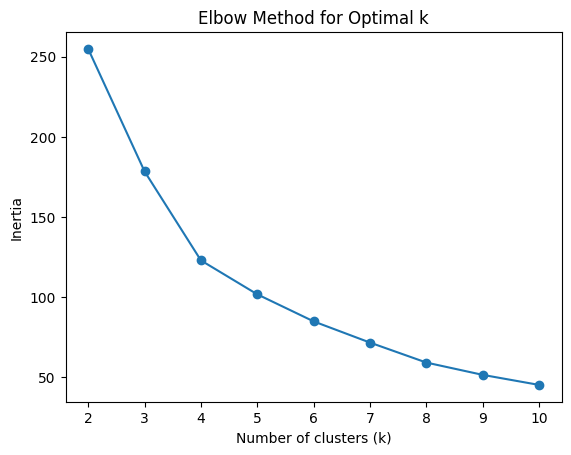

In [23]:
# Using Elbow Method to chooose 'k' :
inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()


In [24]:
# Applying K-Means :
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_pca)

pca_df["Cluster"] = clusters


Visualization : PCA Clusters

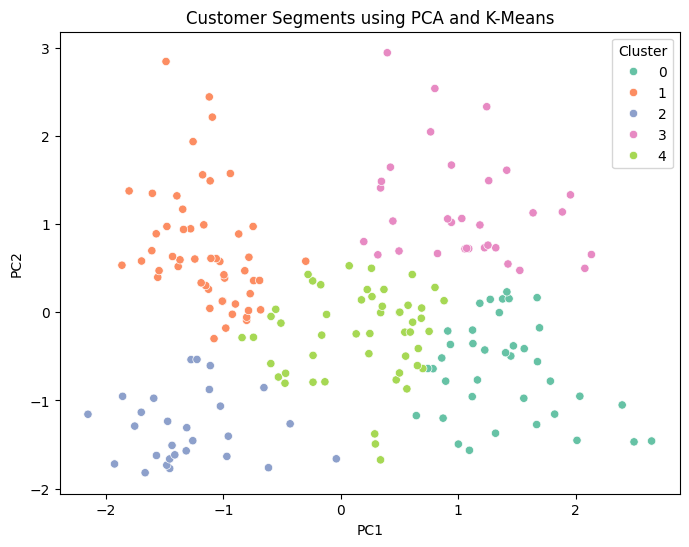

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="PC1", y="PC2",
    hue="Cluster",
    palette="Set2",
    data=pca_df
)
plt.title("Customer Segments using PCA and K-Means")
plt.show()


Visualization : Original features

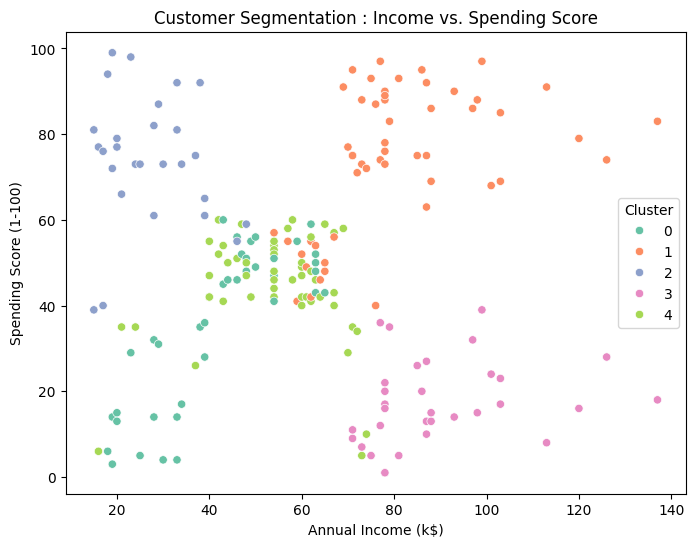

In [25]:
df["Cluster"] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    data=df
)
plt.title("Customer Segmentation : Income vs. Spending Score")
plt.show()


Cluster Analysis & Conclusion
Based on the K-Means clustering, we identified 5 distinct customer segments:

1. Sensible Shoppers: High Income, Low Spending. (Target for "value" promotions).

2. Careless Spenders: Low Income, High Spending.

3. Target Customers (VIPs): High Income, High Spending. (This is the ideal group for premium marketing).

4. Standard Customers: Moderate Income, Moderate Spending.

5. Budget Customers: Low Income, Low Spending.